# M01: equivalent SDOF vs 3D NLTHA

Compares, for archetype **M01** in both directions:

1. **Peak displacements**: SDOF NLTHA (`Pushover_SDOF/ResultsM01x_SDOF`, `ResultsM01y_SDOF`) vs 3D NLTHA
   (`M01_biron_DispX.txt`, `M01_biron_DispY.txt`, largest peak over the braced nodes).
   The SDOF displacement is converted to the braced nodes with `SDOF_FACTOR`, by default
   $\Gamma \cdot \max\phi$ over the spring DOFs of the 2D pushover step the SDOF was built from.
   IMs or records the SDOF analyses have not reached yet are left out; rerun the notebook to update.
2. **Displaced shapes**: mean ± 2σ of the 3D NLTHA shapes (`M01_bironDispShapeX/Y.npy`) vs the equivalent
   static shape (`Pushover2D/pushover_results_M01x/y.txt`), on the plan of the 3D model, whole system
   and zoomed on the line analysed by the 2D model.
3. **Pushover curves**: 3D static pushover (`M01_biron_pushoverX/Y.txt`, from
   `3D_models/pushover_3d.py`) vs the 2D adaptive pushover and the SDOF pushover.

Helpers in [nltha_comparison.py](nltha_comparison.py).

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from nltha_comparison import *

mpl.rc('font', family='Times New Roman')
mpl.rc('mathtext', fontset='stix')
%matplotlib inline

In [2]:
MODEL       = 'M01'
DC_TARGET   = 12.0          # 2D pushover step (mm) of the SDOF calibration and of the static shape
SDOF_FACTOR = 'gamma_phi'   # SDOF -> braced-node displacement: 'gamma_phi', a number, or {'X': .., 'Y': ..}
SHAPE_IM    = 6             # intensity level (1-10) of the NLTHA displaced shapes
AMP         = None          # amplification of the displaced shapes (m per unit); None = automatic

## Peak displacements

In [3]:
comp = peak_comparison(MODEL, factor=SDOF_FACTOR, dc_target=DC_TARGET)
peak_table(comp)

X                                       Y                      \
   3D (mm) SDOF (mm) SDOF / 3D n 3D / SDOF 3D (mm) SDOF (mm) SDOF / 3D   
IM                                                                       
1    1.615     1.814     1.123     44 / 44   1.535     1.484     0.967   
2    3.370     3.836     1.138     44 / 44   3.250     3.095     0.952   
3    5.055     5.957     1.178     44 / 44   4.970     4.784     0.963   
4    6.570     7.745     1.179     44 / 44   6.240     6.211     0.995   
5    8.915    10.624     1.192     44 / 44   8.850     8.785     0.993   
6   10.930    12.571     1.150     44 / 44  10.590    10.246     0.968   
7   12.325    14.534     1.179     44 / 44  11.875    11.807     0.994   
8   13.980    15.992     1.144     44 / 44  12.945    13.055     1.008   
9   15.455    17.954     1.162     44 / 44  14.485    14.561     1.005   
10  17.000    19.362     1.139     44 / 44  15.385    15.288     0.994   

                
   n 3D / SDOF  
IM              
1      44 / 44  
2      44 / 44  
3      44 / 44  
4      44 / 44  
5      44 / 44  
6      44 / 44  
7      44 / 44  
8      44 / 44  
9      44 / 44  
10     44 / 44

Median (markers) and 16th–84th percentiles (bars) over the records.

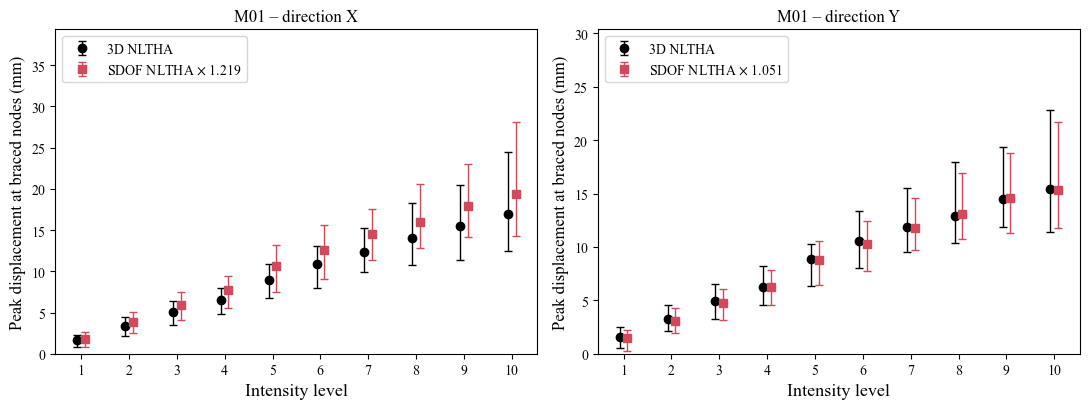

In [4]:
plot_peak_medians(MODEL, comp)
plt.show()

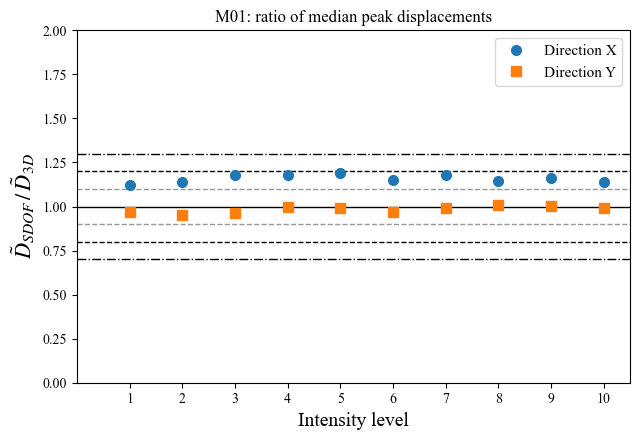

In [5]:
plot_peak_ratio(MODEL, comp)
plt.show()

Record by record (same record and IM in both analyses); dashed lines at ±20 %.

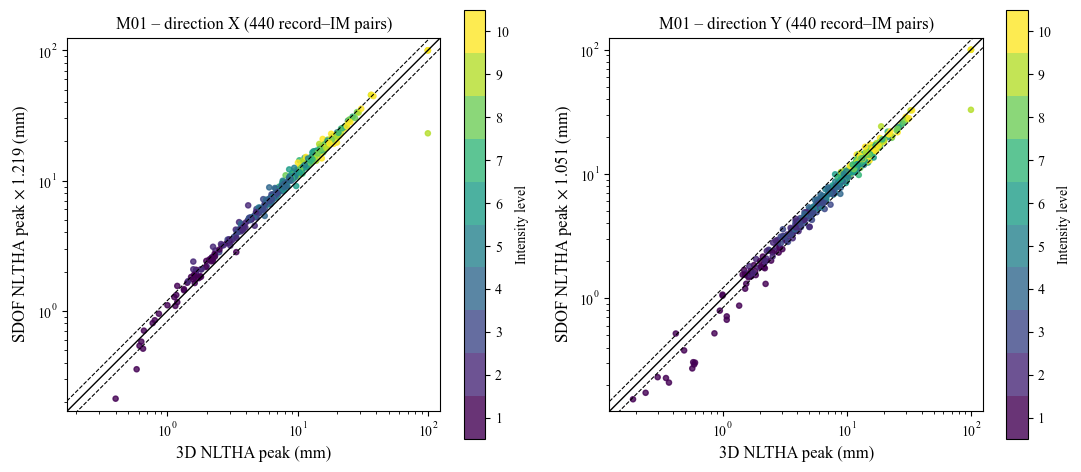

In [6]:
plot_peak_records(MODEL, comp)
plt.show()

## Pushover curves

Base shear vs displacement at the reference node of the 2D model (the normalization node of the displaced shapes): 3D static pushover under a mass-proportional load (`3D_models/pushover_3d.py`, run it first), 2D adaptive pushover (`Pushover2D`) and SDOF pushover (`Pushover_SDOF`, displacement × Γ). The star is the 2D step the SDOF was built from.

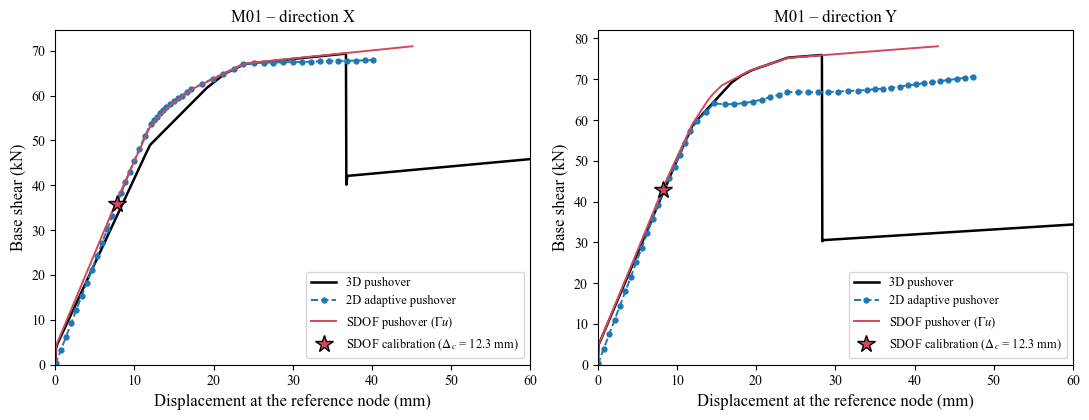

In [7]:
plot_pushover_comparison(MODEL, dc_target=DC_TARGET)
plt.show()

## Displaced shapes

Both shapes are normalized to 1 at the marked node (the reference DOF of the 2D model). The static shape
is mapped onto the 3D plan through the analysed line of the 2D model (`nltha_lines` in
`Pushover2D/CS_Lumped_Iter_M01*_cont_PO.py`): pipes parallel to the excitation move rigidly, other
branches deform as the analysed line.

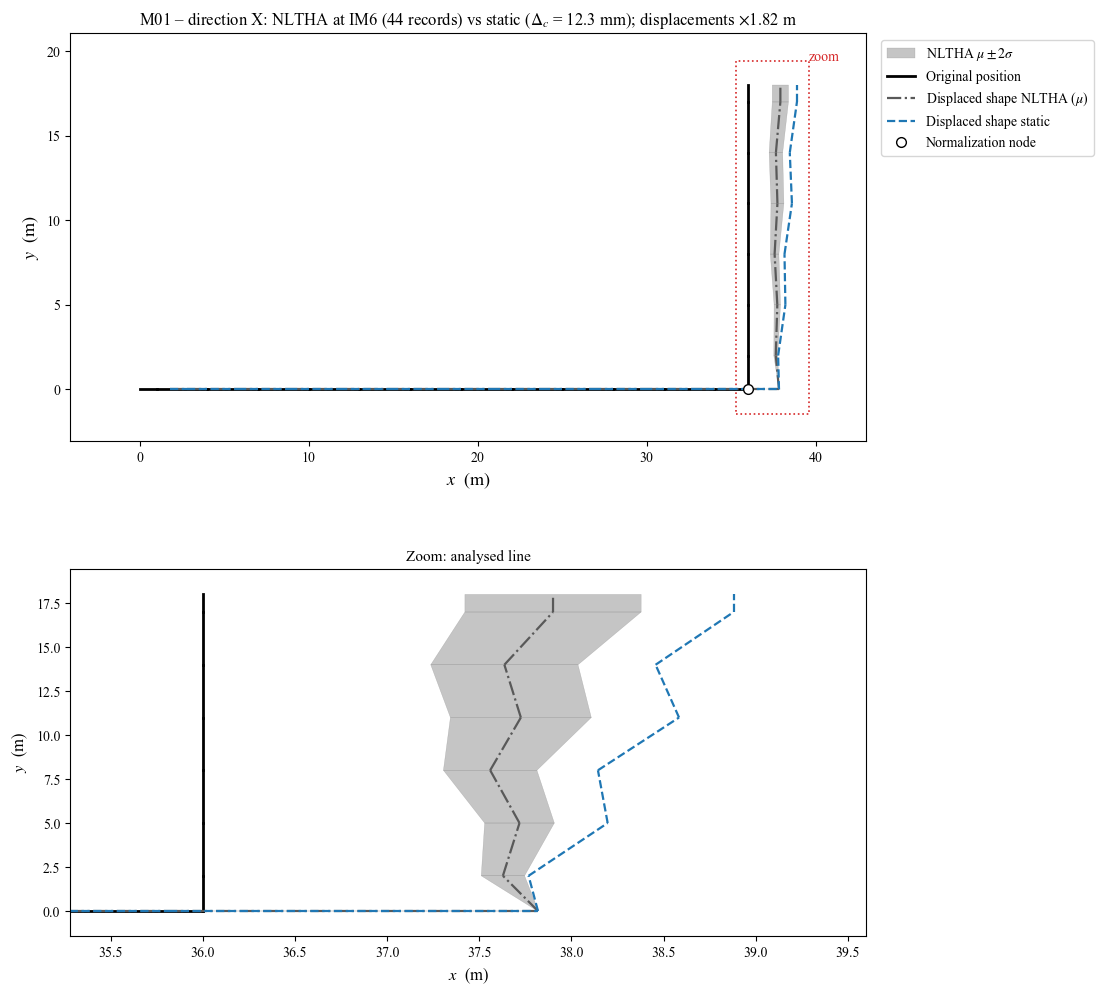

In [8]:
plot_displaced_shape(MODEL, 'X', SHAPE_IM, amp=AMP, dc_target=DC_TARGET)
plt.show()

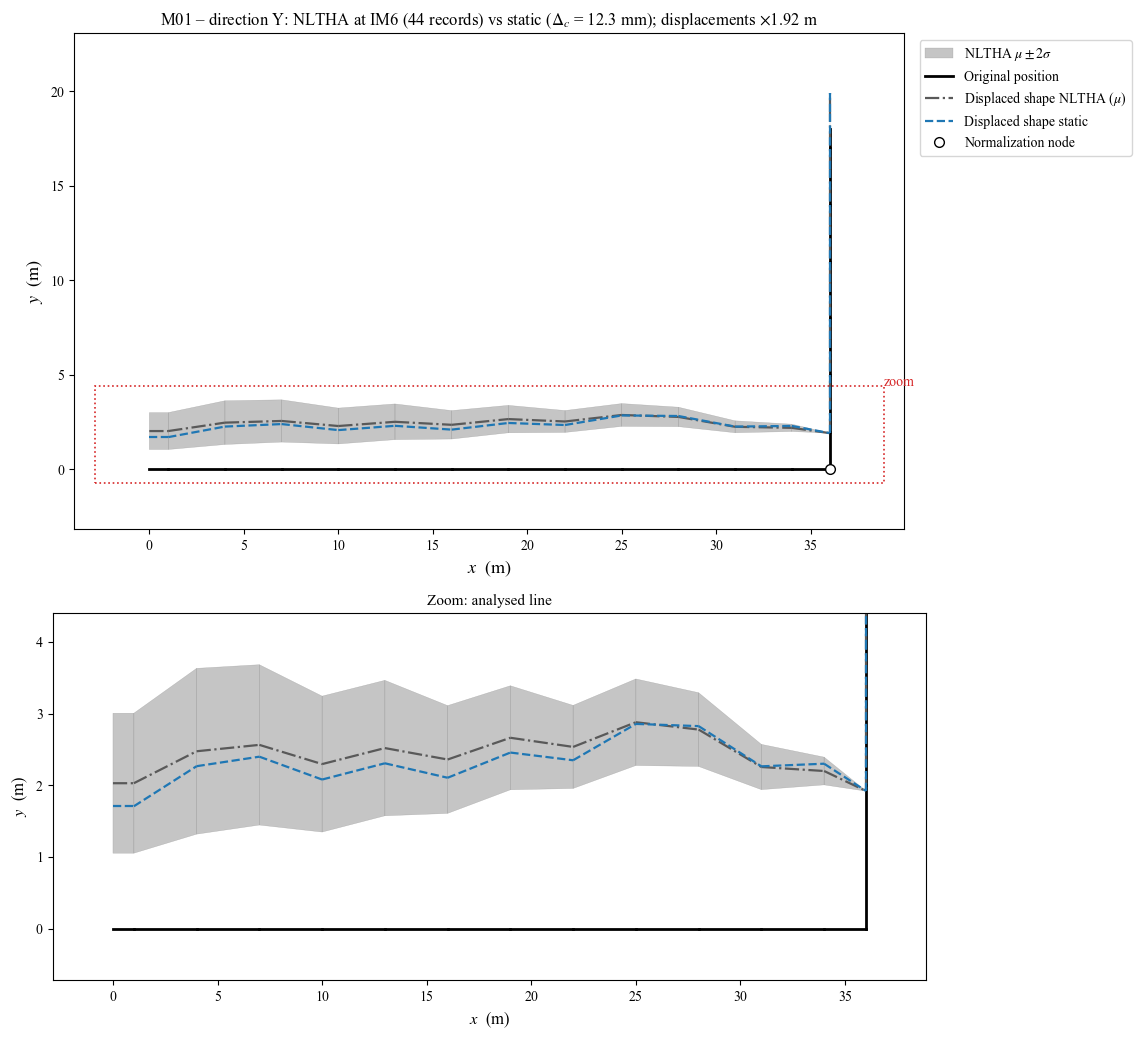

In [9]:
plot_displaced_shape(MODEL, 'Y', SHAPE_IM, amp=AMP, dc_target=DC_TARGET)
plt.show()